
PATIENT DATA
Unique patients: 169
Expression features loaded: 501
EGFR_group
Detected EGFR mutation       94
No detected EGFR mutation    75
Name: count, dtype: int64

Reused saved patient split: EGFR_patient_train_test_split.csv

Training patients: 152
Reserved test patients: 17

Training group counts:
EGFR_status
0    67
1    85
Name: count, dtype: int64

Test group counts:
EGFR_status
0    8
1    9
Name: count, dtype: int64


/opt/anaconda3/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['CD99']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['CD99']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['CD99']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['CD99']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.14/site-packa


TRAINING-ONLY MODEL COMPARISON:
 PLS_components  Training_R2    CV_Q2  CV_balanced_accuracy
              1     0.299002 0.131149              0.633802
              2     0.537020 0.224785              0.769974
              3     0.644116 0.309580              0.774276
              4     0.694510 0.305750              0.798244
              5     0.812034 0.300720              0.813169
              6     0.851952 0.254615              0.758209
              7     0.903377 0.216913              0.792362
              8     0.928460 0.233607              0.798244
              9     0.944286 0.200212              0.790781
             10     0.959500 0.188947              0.783319

SELECTED EGFR PLS-DA MODEL
Selected number of components: 3
Training R²: 0.644
Cross-validated Q²: 0.310
Cross-validated balanced accuracy: 77.4%

Selection rule: highest development cross-validated Q².


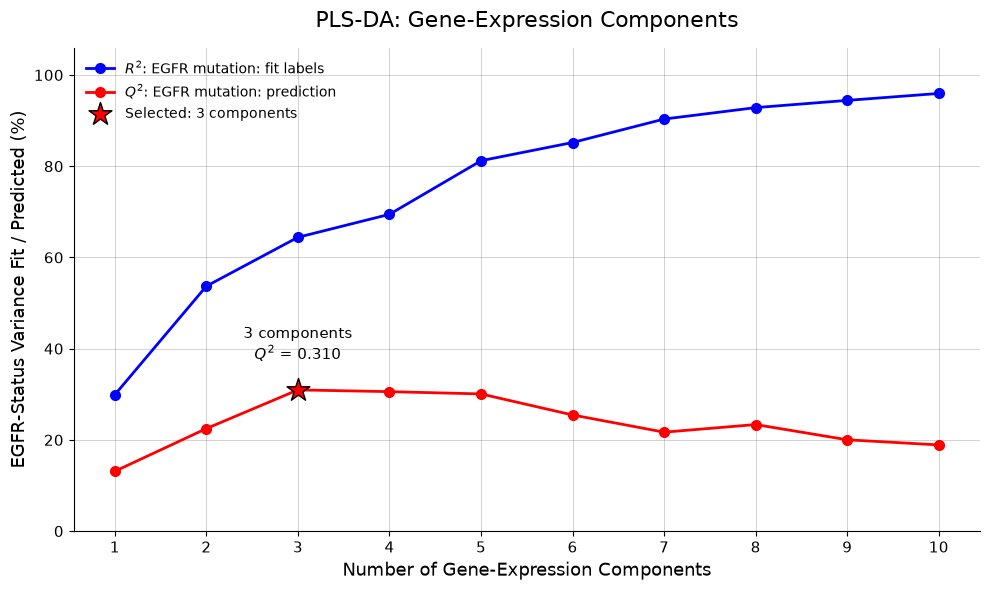

In [1]:
"""
Project: BME 6006 Final Project
Analysis: EGFR mutation status predicted from gene expression
Method: PLS-DA with training-only cross-validation
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, r2_score


clinical_file = "data_clinical_patient_6006_project.xlsx" #patient IDs and sequence info

expression_file = ("data_mrna_seq_v2_rsem_zscores_ref_all_samples_6006_project.xlsx") #gene expression z-score

mutation_file = "mutations_6006_project.xlsx" #mutation records for EGFR-positive patients

# Use the same expression subset as the earlier analysis
# pandas nrows counts data rows after the header
# This is a spreadsheet-order subset, not a selected immune-gene panel
expression_rows = 501

test_fraction = 0.10  #Reserve 10% of patients for final testing
random_seed = 42  #Makes random splitting reproducible with the same data
number_of_folds = 5  #Divide training patients into five cross-validation groups
maximum_components = 10  #Compare models containing up to ten PLS components
classification_threshold = 0.5  #Prediction score > or = 0.5 is classified as mutation-positive

output_folder = Path("output")
output_folder.mkdir(exist_ok=True)

#Checked all three input files before starting the analysis
for filename in [clinical_file, expression_file, mutation_file]:
    if not Path(filename).exists():
        raise FileNotFoundError(
            f"Cannot find '{filename}'. "
            "Put it in the notebook folder or change its name above."
        )

# Read clinical data
clinical = pd.read_excel(clinical_file) #load spreadsheet into dataframe
clinical.columns = clinical.columns.astype(str).str.strip() #make column names and remove surrounding spaces

#Patient-IDs
id_options = [
    "#Patient identifier",
    "Patient identifier",
    "Patient Identifier",
    "PATIENT_ID"
]

clinical_id_column = next(
    (
        column for column in id_options
        if column in clinical.columns
    ),
    None
)

if clinical_id_column is None:
    raise ValueError(
        "Patient ID column not found. Clinical columns are:\n"
        f"{clinical.columns.tolist()}"
    )

required_columns = [
    "Exome Sequencing Status",
    "RNA Sequencing Status"
]

missing_columns = [
    column for column in required_columns
    if column not in clinical.columns
]

if missing_columns:
    raise ValueError(
        f"Missing clinical columns: {missing_columns}"
    )

clinical = clinical.dropna(
    subset=[clinical_id_column]
).copy()

clinical["Patient ID"] = (
    clinical[clinical_id_column]
    .astype(str)
    .str.strip()
)

#Match the original OncoSG cohort restriction
#Patients whose IDs start with B are excluded
clinical = clinical[
    ~clinical["Patient ID"].str.startswith("B")
].copy()

if clinical["Patient ID"].duplicated().any(): #Checks whether any ID appears more than once
    raise ValueError(
        "Clinical data contain duplicate patient IDs."
    )
    
#Keeps patients with paired exome profiling and either tumor-only or paired RNA data
clinical = clinical[
    clinical["Exome Sequencing Status"]
    .astype(str).str.strip().str.lower().eq("paired")
    &
    clinical["RNA Sequencing Status"]
    .astype(str).str.strip().str.lower()
    .isin(["tumor", "paired"])
].copy()

#Gene-expression data
expression = pd.read_excel( #Read only initial expression subset specified
    expression_file,
    nrows=expression_rows
)

expression.columns = ( #expression-file column names
    expression.columns.astype(str).str.strip()
)

gene_column = expression.columns[0] #gene-symbol column; stores eligible IDs for matching
clinical_ids = set(clinical["Patient ID"])

sample_columns = [ #Selects only expression columns whose names match eligible patient IDs
    column for column in expression.columns
    if column in clinical_ids
]

if not sample_columns: #Stops if no expression sample IDs matched clinical data
    raise ValueError(
        "No expression sample columns matched clinical patient IDs."
    )

expression = expression.dropna( #Removed expression rows w/o gene identifier
    subset=[gene_column]
).copy()

expression[gene_column] = ( 
    expression[gene_column].astype(str).str.strip()
)

if expression[gene_column].duplicated().any():
    raise ValueError(
        "Duplicate gene symbols found. Resolve them before modeling."
    )

#Now rows are patients, columns are genes.
expression_by_patient = (
    expression.set_index(gene_column)[sample_columns].T
)

expression_by_patient.index.name = "Patient ID" #Names the index containing Patient IDs

expression_by_patient = (
    expression_by_patient.reset_index() #Move Patient IDs from the index into normal column
)

if expression_by_patient["Patient ID"].duplicated().any():
    raise ValueError(
        "Expression data contain duplicate patient IDs."
    )

gene_columns = [ #Expression predictors
    column for column in expression_by_patient.columns
    if column != "Patient ID"
]

#EGFR mutation records
mutations = pd.read_excel( #uses third dataset row as column name
    mutation_file,
    header=2
)

mutations.columns = (
    mutations.columns.astype(str).str.strip() # Clean mutation table column names
)

required_mutation_columns = [
    "Hugo_Symbol",  #Identifies which gene contains the mutation
    "Tumor_Sample_Barcode"  #Identifies the sample associated with each mutation record
]

missing_columns = [
    column for column in required_mutation_columns
    if column not in mutations.columns
]

if missing_columns:
    raise ValueError(
        f"Missing mutation columns: {missing_columns}. "
        "Check whether header=2 is correct for the mutation file."
    )
#Keep only EGFR mutation records and their sample IDs
#.loc selects rows using the condition, then selects the requested columns

egfr_records = mutations.loc[
    mutations["Hugo_Symbol"]
    .astype(str).str.strip().eq("EGFR"),
    ["Tumor_Sample_Barcode"]
].dropna().copy()

egfr_records["Patient ID"] = (
    egfr_records["Tumor_Sample_Barcode"]
    .astype(str)
    .str.strip()
)

#One label per patient, even if there are more than one mutation
#A set contains each ID only once avoiding duplicate expression rows
egfr_positive_ids = set(egfr_records["Patient ID"])

#Match expression data to EGFR labels
patient_data = expression_by_patient.merge(
    clinical[["Patient ID"]],
    on="Patient ID",  #Match expression and clinical rows using their IDs
    how="inner",  #Keep only IDs present in both tables
    validate="one_to_one"  #Stop if the merge would repeat a patient
)

#Assumes the mutation file is the complete mutation export for the included exome-profiled patients
#1 means an EGFR record was detected; 0 means no matching EGFR record
patient_data["EGFR_status"] = (
    patient_data["Patient ID"]
    .isin(egfr_positive_ids) #True if the patient is in the EGFR-record ID set
    .astype(int) #Converts True/False to 1/0
)

patient_data["EGFR_group"] = (
    patient_data["EGFR_status"].map({ #Adds readable names for the two labels
        0: "No detected EGFR mutation",
        1: "Detected EGFR mutation"
    })
)

#X contains only gene-expression predictors
#Unreadable values and infinite values become NaN for later preprocessing
X = patient_data[gene_columns].apply(
    pd.to_numeric,
    errors="coerce"
).replace([np.inf, -np.inf], np.nan)

y = patient_data["EGFR_status"].astype(int)  #y contains the 0/1 outcome to predict
patient_ids = patient_data["Patient ID"]  #Keep IDs to track train/test membership

if y.nunique() != 2: #Model needs both mutation-positive and -negative labels
    raise ValueError(
        "Both EGFR groups are required. Check mutation ID matching."
    )

print("\nPATIENT DATA")
print("Unique patients:", len(patient_data))  # # of patient rows after matching
print("Expression features loaded:", X.shape[1])  # # of expression predictor columns
print(patient_data["EGFR_group"].value_counts())  # # of patients in each group

#90% used, 10% patients left out
split_candidates = [
    Path("EGFR_patient_train_test_split.csv"),
    output_folder / "EGFR_patient_train_test_split.csv"
]

saved_split_file = next(
    (path for path in split_candidates if path.exists()),
    None
)

if saved_split_file is not None:

    assignments = pd.read_csv(
        saved_split_file,
        dtype={"Patient ID": str} #Preserves patitent IDs as text
    )

    required_split_columns = [
        "Patient ID",
        "EGFR_status",
        "Dataset"
    ]
#confirms saved file contains every required column
    if not set(required_split_columns).issubset(assignments.columns):
        raise ValueError(
            "Saved split must have Patient ID, EGFR_status, "
            "and Dataset columns."
        )

    assignments["Patient ID"] = (
        assignments["Patient ID"].str.strip()
    )

    if assignments["Patient ID"].duplicated().any():
        raise ValueError(
            "Saved split contains duplicate patient IDs."
        )

    if set(assignments["Patient ID"]) != set(patient_ids):
        raise ValueError(
            "Saved split does not match the current patient cohort. "
            "Check that everyone is using the same input files."
        )

    indexed_data = patient_data.set_index("Patient ID") #Allows selection by Patient ID

    saved_labels = pd.to_numeric(
        assignments["EGFR_status"],
        errors="raise" #Convert the saved labels to NumPy array
    ).to_numpy()

    current_labels = indexed_data.loc[ #Obtains current labels in same order as saved assignments
        assignments["Patient ID"],
        "EGFR_status"
    ].to_numpy()

    if not np.array_equal(saved_labels, current_labels):
        raise ValueError(
            "Mutation labels do not match those in the saved split."
        )

    #Every assignment must say Training or Test
    if not assignments["Dataset"].isin(["Training", "Test"]).all():
        raise ValueError(
            "Saved Dataset labels must be Training or Test."
        )

    train_ids = assignments.loc[
        assignments["Dataset"].eq("Training"),
        "Patient ID"
    ].tolist() #Lists the saved training IDs in their saved order

    test_ids = assignments.loc[
        assignments["Dataset"].eq("Test"),
        "Patient ID"
    ].tolist() #List the saved testing IDs in their saved order

    #Select expression values for training patients
    X_train = indexed_data.loc[
        train_ids, gene_columns
    ].apply(
        pd.to_numeric, errors="coerce"
    ).replace([np.inf, -np.inf], np.nan)

    #Select expression values for test patients; do not use them to select components
    X_test = indexed_data.loc[
        test_ids, gene_columns
    ].apply(
        pd.to_numeric, errors="coerce"
    ).replace([np.inf, -np.inf], np.nan)

    y_train = indexed_data.loc[
        train_ids, "EGFR_status"
    ].astype(int) #Corrects mutation labels for the training patients

    y_test = indexed_data.loc[
        test_ids, "EGFR_status"
    ].astype(int) #Corrects mutation labels for the reserved test patients

    ids_train = np.asarray(train_ids) #Convert ID lists to arrays
    ids_test = np.asarray(test_ids)

    print("\nReused saved patient split:", saved_split_file)

else:

    (
        X_train,
        X_test,
        y_train,
        y_test,
        ids_train,
        ids_test
    ) = train_test_split(
        X,
        y,
        patient_ids,
        test_size=test_fraction,  #Reserve approximately 10% for final testing
        random_state=random_seed,  #Reproducible random selection
        stratify=y  #Preserve approximately the same class proportions in both sets
    )
#Combines training and test assignments into one record of the split
    assignments = pd.concat([
        pd.DataFrame({
            "Patient ID": np.asarray(ids_train),
            "EGFR_status": np.asarray(y_train),
            "Dataset": "Training"
        }),
        pd.DataFrame({
            "Patient ID": np.asarray(ids_test),
            "EGFR_status": np.asarray(y_test),
            "Dataset": "Test"
        })
    ], ignore_index=True)

    print("\nCreated a 90%/10% split using random seed 42.")

assignments.to_csv(
    output_folder / "EGFR_patient_train_test_split.csv",
    index=False
)

#Stops run if any patient appears in both training and testing
assert set(ids_train).isdisjoint(set(ids_test))

print("\nTraining patients:", len(X_train))
print("Reserved test patients:", len(X_test))

print("\nTraining group counts:")
print(y_train.value_counts().sort_index())

print("\nTest group counts:")
print(y_test.value_counts().sort_index())

#PLSDA model
#Runs a fresh process each time its called
def make_preprocessing():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")), #Fill missing values using fitted training medians
        ("remove_constant", VarianceThreshold(threshold=0.0)), #Removes zero-variance features
        ("scaler", StandardScaler()) #Centers each feature and scale by its fitted training standard deviation
    ])

def make_model(n_components):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("remove_constant", VarianceThreshold(threshold=0.0)),
        ("scaler", StandardScaler()),
        (
            "pls",
            PLSRegression(
                n_components=n_components,  #Number of gene-expression summary components
                scale=False,  #Avoid scaling again inside PLS
                max_iter=1000  #Maximum iterations allowed for the PLS fitting algorithm
            )
        )
    ])

#EGFR Mutation: Training-only cross-validation

X_development = X_train.copy()  #Works only with the training expression data
y_development = y_train.to_numpy(dtype=float)  #Converts labels to floating-point numbers for PLS

class_counts = pd.Series(y_development).value_counts() #Counts patients in each training class

if len(class_counts) != 2 or class_counts.min() < number_of_folds:
    raise ValueError(
        "Each EGFR group needs at least five training patients."
    )

cv = StratifiedKFold(
    n_splits=number_of_folds,  #Five groups within the training dataset
    shuffle=True,  #Randomize membership before creating the folds
    random_state=random_seed  #Keep fold membership reproducible
)

#Each development patient is in the validation portion once
folds = list(cv.split(X_development, y_development))
fold_limits = [] #Store feasible component-count limits for each fold

#Fit preprocessing using only this fold's fitting patients
#.iloc selects rows by integer position
for train_index, validation_index in folds:

    processed_fold_X = make_preprocessing().fit_transform(
        X_development.iloc[train_index]
    )

    fold_limits.append(
        min(
            processed_fold_X.shape[1], #Limit based on the number of usable features
            processed_fold_X.shape[0] - 1 #Limit based on centered training sample count
        )
    )

max_components = min(
    maximum_components,  #Not exceeding the planned maximum of ten
    min(fold_limits)  #Remain feasible in every fold
)

if max_components < 1:
    raise ValueError(
        "No usable expression features remain in a training fold."
    )

total_sum_squares = np.sum(
    (y_development - y_development.mean()) ** 2
)

component_results = []
cv_predictions = {}

for n_components in range(1, max_components + 1):

    held_out_scores = np.full(
        len(y_development),
        np.nan
    )

    for train_index, validation_index in folds:

        model = make_model(n_components)

        model.fit(
            X_development.iloc[train_index],
            y_development[train_index]
        )

        held_out_scores[validation_index] = (
            model.predict(
                X_development.iloc[validation_index]
            ).ravel()
        )

    if not np.isfinite(held_out_scores).all():
        raise ValueError(
            "Invalid cross-validation predictions were produced."
        )

    prediction_error = np.sum(
        (y_development - held_out_scores) ** 2
    )

    q2 = 1 - prediction_error / total_sum_squares

    held_out_classes = (
        held_out_scores >= classification_threshold
    ).astype(int)

    balanced_accuracy = balanced_accuracy_score(
        y_development.astype(int),
        held_out_classes
    )

    full_training_model = make_model(n_components)

    full_training_model.fit(
        X_development,
        y_development
    )

    training_scores = (
        full_training_model.predict(
            X_development
        ).ravel()
    )

    training_r2 = r2_score(
        y_development,
        training_scores
    )

    component_results.append({
        "PLS_components": n_components,
        "Training_R2": training_r2,
        "CV_Q2": q2,
        "CV_balanced_accuracy": balanced_accuracy
    })

    cv_predictions[n_components] = held_out_scores

component_results_df = pd.DataFrame(component_results)

#Highest cross-validated (Q^2)
# Sort by highest Q² first; in an exact tie, choose fewer components
#.iloc[0] selects the first row of the sorted table
best_row = component_results_df.sort_values(
    ["CV_Q2", "PLS_components"],
    ascending=[False, True]
).iloc[0]

best_components = int(best_row["PLS_components"])  #Selected component count
best_r2 = float(best_row["Training_R2"])  #Selected model's training fit
best_q2 = float(best_row["CV_Q2"])  #Selected model's development prediction score

print("\nTRAINING-ONLY MODEL COMPARISON:")
print(component_results_df.to_string(index=False)) #Print all results without a row-index column

print("\nSELECTED EGFR PLS-DA MODEL")
print(f"Selected number of components: {best_components}")
print(f"Training R²: {best_r2:.3f}")
print(f"Cross-validated Q²: {best_q2:.3f}")

print(
    "Cross-validated balanced accuracy: "
    f"{best_row['CV_balanced_accuracy']:.1%}" #Display accuracy as a percentage with one decimal place
)

print(
    "\nSelection rule: highest development cross-validated Q²."
)

#These CV scores helped choose the model, so they are development results
#The reserved test patients are not evaluated anywhere in this code block

#PLSDA plot
components = (component_results_df["PLS_components"].to_numpy())

r2_percent = (component_results_df["Training_R2"].to_numpy() * 100) #Show R^2 on a percentage-style scale

q2_percent = (component_results_df["CV_Q2"].to_numpy() * 100) #Show Q^2 on the same scale

fig, ax = plt.subplots(figsize=(10, 6)) #Create a figure and axes; dimensions in inches
ax.plot(
    components,
    r2_percent,
    color="blue",
    marker="o", #Circular markers at the calculated component counts
    markersize=7,
    linewidth=2,
    label=r"$R^2$: EGFR mutation: fit labels"
)

#Place star at component count selected using cross-validation
ax.plot(
    components,
    q2_percent,
    color="red",
    marker="o",
    markersize=7,
    linewidth=2,
    label=r"$Q^2$: EGFR mutation: prediction"
)

ax.scatter(
    best_components,
    best_q2 * 100,
    marker="*",
    s=300,
    color="red",
    edgecolor="black",
    linewidth=1,
    zorder=5,
    label=f"Selected: {best_components} components"
)

#Location of annotations
ax.annotate(
    f"{best_components} components\n"
    rf"$Q^2$ = {best_q2:.3f}",
    xy=(best_components, best_q2 * 100),
    xytext=(0, 18),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=11
)

ax.set_xlabel("Number of Gene-Expression Components",fontsize=13)
ax.set_ylabel("EGFR-Status Variance Fit / Predicted (%)",fontsize=13)
ax.set_title("PLS-DA: Gene-Expression Components",fontsize=16,pad=15)
ax.set_xticks(components)

lowest_score = min(float(np.min(r2_percent)),float(np.min(q2_percent)))
ax.set_ylim(min(0, lowest_score - 5),max(105,float(np.max(r2_percent)) + 10,float(np.max(q2_percent)) + 15))
ax.legend(loc="upper left",fontsize=10,frameon=False)
ax.set_axisbelow(True)
ax.grid(True,axis="both",linestyle="-",color="gray",linewidth=0.7,alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)
plt.tight_layout()

fig.savefig(
    output_folder / "EGFR_PLSDA_R2_Q2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Selected PLS components: 3
Expression features used after preprocessing: 500

FINAL HELD-OUT TEST RESULTS
Test patients: 17
Correct classifications: 15 out of 17
Accuracy: 0.882
Balanced accuracy: 0.875
ROC AUC: 0.972
Sensitivity—detected mutation group: 1.000
Specificity—no detected mutation group: 0.750
Test R² on numerical labels: 0.512
Squared-error skill vs training-mean baseline: 0.514

MAJORITY-CLASS BASELINE
Accuracy: 0.529
Balanced accuracy: 0.500


/opt/anaconda3/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['CD99']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['CD99']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['CD99']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


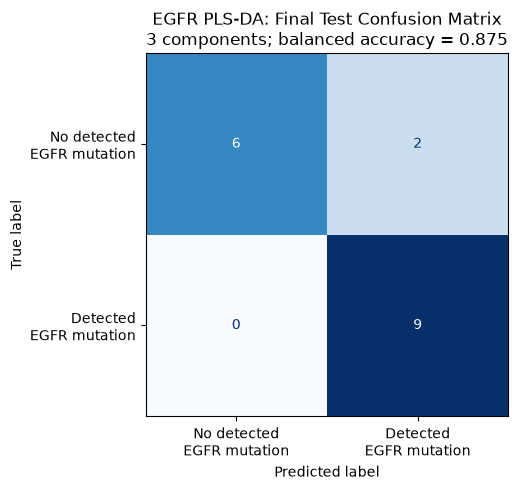


Individual test predictions:
Patient ID  True_EGFR_status  Predicted_score  Predicted_EGFR_status                True_group           Predicted_group  Correct
      A021                 1         0.785971                      1    Detected EGFR mutation    Detected EGFR mutation     True
      A131                 0        -0.492656                      0 No detected EGFR mutation No detected EGFR mutation     True
      A190                 0        -0.096808                      0 No detected EGFR mutation No detected EGFR mutation     True
      A208                 0         0.301207                      0 No detected EGFR mutation No detected EGFR mutation     True
      A148                 1         0.829581                      1    Detected EGFR mutation    Detected EGFR mutation     True
      A316                 1         0.883527                      1    Detected EGFR mutation    Detected EGFR mutation     True
      A249                 1         0.768461               

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    r2_score
)

#Fit the model on training patients only
#These conversions make arrays
training_labels = np.asarray(y_train, dtype=float).ravel()
test_true_labels = np.asarray(y_test, dtype=int).ravel()
test_patient_ids = np.asarray(ids_test).ravel()

#Used to verify lengths and correct patient ordering in earlier split
#Each expression should have a label 
if len(X_train) != len(training_labels):
    raise ValueError(
        "Training expression rows and training labels do not match."
    )

if len(X_test) != len(test_true_labels):
    raise ValueError(
        "Test expression rows and test labels do not match."
    )

if len(test_patient_ids) != len(test_true_labels):
    raise ValueError(
        "Test patient IDs and test labels do not match."
    )

print("Selected PLS components:", best_components) #Print selected component count

#Create the final pipeline
#All preprocessing settings are fitted using training patients only
final_plsda = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), #Fill gaps using each feature's training median
    ("remove_constant", VarianceThreshold(threshold=0.0)), #Remove features with zero training variance
    ("scaler", StandardScaler()), #Put expression features on comparable training-based scales
    (
        "pls",
        PLSRegression(
            n_components=best_components, #Use the count selected by CV
            scale=False, #Avoid scaling again inside PLSDA
            max_iter=1000
        )
    )
])

#final_plsda[:-1] contains all pipeline steps except the final PLSDA model
final_plsda.fit(
    X_train,
    training_labels
)

processed_training_data = final_plsda[:-1].transform(X_train)

print(
    "Expression features used after preprocessing:",
    processed_training_data.shape[1] #Number of gene-expression columns reaching the model
)

#Predict reserved testing patients
#Apply training-fitted preprocessing to the test expression measurements, then use the fitted PLSDA model to produce 1 numerical score per patient
test_scores = final_plsda.predict(X_test).ravel()

#Keep the original fixed classification threshold; not probabilities

test_predictions = (test_scores >= 0.5).astype(int)

#Calculate test performance
#Compare each predicted group with the corresponding actual group
test_accuracy = accuracy_score(
    test_true_labels,
    test_predictions
)

test_balanced_accuracy = balanced_accuracy_score(
    test_true_labels,
    test_predictions
)

test_auc = (
    roc_auc_score(test_true_labels, test_scores)
    if len(np.unique(test_true_labels)) == 2
    else np.nan
)
#Test R^2 compares numerical labels with numerical prediction scores;separate from development CV Q^2
test_r2 = (
    r2_score(test_true_labels, test_scores)
    if len(test_true_labels) >= 2
    else np.nan
)

training_mean_label = float(training_labels.mean())

#Total squared numerical prediction error from the PLSDA model
model_squared_error = np.sum(
    (test_true_labels - test_scores) ** 2
)

#Total error if every test patient receives the same training-mean score
baseline_squared_error = np.sum(
    (test_true_labels - training_mean_label) ** 2
)

#Positive skill means less squared error than training-mean baseline
#Negative skill means more error
test_skill_vs_training_mean = (
    1 - model_squared_error / baseline_squared_error
    if baseline_squared_error > 0
    else np.nan
)

#Majority-class baseline based on training labels only
#.mode() finds the most common training label
majority_class = int(
    pd.Series(training_labels.astype(int)).mode().iloc[0]
)

#Predict that same majority class for every test patient
majority_predictions = np.full(
    len(test_true_labels),
    majority_class
)

#Compare the simple majority-class strategy with the PLSDA model
baseline_accuracy = accuracy_score(
    test_true_labels,
    majority_predictions
)

#Build the actual data plotted in the 4x4 matrix
#Rows = true groups and columns = predicted groups
# labels=[0, 1] fixes the order: no detected mutation first, detected mutation second
baseline_balanced_accuracy = balanced_accuracy_score(
    test_true_labels,
    majority_predictions
)

cm = confusion_matrix(
    test_true_labels,
    test_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

#Fraction of actual mutation-negative patients identified correctly
specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else np.nan
)

#Fraction of actual mutation-positive patients identified correctly
sensitivity = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else np.nan
)

print("\nFINAL HELD-OUT TEST RESULTS")
print("=" * 50) #Prints divider
print("Test patients:", len(test_true_labels))

print(
    "Correct classifications:",
    int(np.sum(test_true_labels == test_predictions)), #Count actual and predicted labels
    "out of",
    len(test_true_labels)
)

print(f"Accuracy: {test_accuracy:.3f}")
print(f"Balanced accuracy: {test_balanced_accuracy:.3f}")
print(f"ROC AUC: {test_auc:.3f}")

print(
    "Sensitivity—detected mutation group:",
    f"{sensitivity:.3f}"
)

print(
    "Specificity—no detected mutation group:",
    f"{specificity:.3f}"
)

print(f"Test R² on numerical labels: {test_r2:.3f}")

print(
    "Squared-error skill vs training-mean baseline:",
    f"{test_skill_vs_training_mean:.3f}"
)

print("\nMAJORITY-CLASS BASELINE")
print(f"Accuracy: {baseline_accuracy:.3f}")
print(f"Balanced accuracy: {baseline_balanced_accuracy:.3f}")

#Plot test matrix
fig, ax = plt.subplots(figsize=(7, 5))

#display 2x2 matrix
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No detected\nEGFR mutation", # \n puts the label on two lines
        "Detected\nEGFR mutation"
    ]
)

#Each square's printed number is its patient count
#Darker blue indicates a larger count
display.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d"
)

ax.set_title(
    "EGFR PLS-DA: Final Test Confusion Matrix\n"
    f"{best_components} components; "
    f"balanced accuracy = {test_balanced_accuracy:.3f}"
)

plt.tight_layout()
plt.show()

#Print individual test predicitions
#Make one row per test patient
#All arrays keep same order so each ID matches its labels and score
test_results_df = pd.DataFrame({
    "Patient ID": test_patient_ids,
    "True_EGFR_status": test_true_labels,  #Label from mutation data
    "Predicted_score": test_scores,  #Continuous PLSDA output
    "Predicted_EGFR_status": test_predictions  #Predicted 0/1 class
})

#Convert numerical labels into group descriptions
group_names = {
    0: "No detected EGFR mutation",
    1: "Detected EGFR mutation"
}

#True means predicted group matches actual and flase means patient matching didn't match
test_results_df["True_group"] = (
    test_results_df["True_EGFR_status"].map(group_names)
)

test_results_df["Predicted_group"] = (
    test_results_df["Predicted_EGFR_status"].map(group_names)
)

test_results_df["Correct"] = (
    test_results_df["True_EGFR_status"]
    == test_results_df["Predicted_EGFR_status"]
)

test_results_df.to_csv(
    "EGFR_PLSDA_final_test_predictions.csv",
    index=False
)

print("\nIndividual test predictions:")
print(test_results_df.to_string(index=False))

print("\nSaved EGFR_PLSDA_final_test_predictions.csv")